#NOME: LUIS FERNANDO DE AZEVEDO
#RM: 574167

In [13]:
import pandas as pd



---
# 1 - Appliances Energy Prediction (UCI)




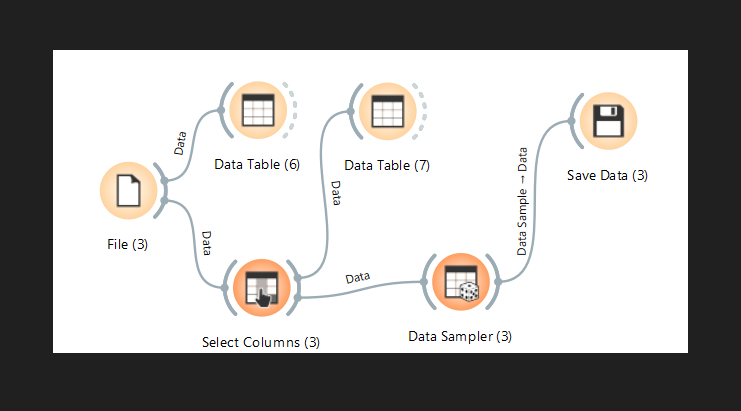

In [3]:
dados = pd.read_csv("/content/Appliances Energy Prediction .csv")
print("---HEAD---")
dados.head()

---HEAD---


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000




---



Renomear Dados

In [4]:
dados = dados.rename(
    columns={
        "Appliances": "Consumo_Eletrodomesticos",
        "T1": "Temp_Cozinha",
        "RH_1": "Umidade_Cozinha",
        "T2": "Temp_Sala",
        "RH_2": "Umidade_sala",
        "T3": "Temp_banheiro",
        "RH_3": "Umidade_banheiro",
    })
dados.head()

,Consumo_Eletrodomesticos,lights,Temp_Cozinha,Umidade_Cozinha,Temp_Sala,Umidade_sala,Temp_banheiro,Umidade_banheiro
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000




---



Inspeções Iniciais

In [5]:
print("\n---SHAPE---")
print(dados.shape)


---SHAPE---
(1974, 8)


In [6]:
print("\n---DADOS INFO---")
dados.info()


---DADOS INFO---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Consumo_Eletrodomesticos  1974 non-null   int64  
 1   lights                    1974 non-null   int64  
 2   Temp_Cozinha              1974 non-null   float64
 3   Umidade_Cozinha           1974 non-null   float64
 4   Temp_Sala                 1974 non-null   float64
 5   Umidade_sala              1974 non-null   float64
 6   Temp_banheiro             1974 non-null   float64
 7   Umidade_banheiro          1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [7]:
print("\n--- DESCRIBE ---")
print(dados.describe())


--- DESCRIBE ---
       Consumo_Eletrodomesticos       lights  Temp_Cozinha  Umidade_Cozinha  \
count               1974.000000  1974.000000   1974.000000      1974.000000   
mean                  93.044580     3.839919     21.664703        40.219193   
std                   93.826149     7.937076      1.574883         3.971923   
min                   20.000000     0.000000     16.790000        27.733300   
25%                   50.000000     0.000000     20.700000        37.205825   
50%                   60.000000     0.000000     21.600000        39.590000   
75%                  100.000000     0.000000     22.600000        42.991675   
max                  770.000000    50.000000     26.260000        57.496700   

         Temp_Sala  Umidade_sala  Temp_banheiro  Umidade_banheiro  
count  1974.000000   1974.000000    1974.000000       1974.000000  
mean     20.293635     40.411386      22.231615         39.209733  
std       2.126958      4.037686       1.957275          3.288818 



---



Maior Consumo

In [8]:
maior_consumo = dados["Consumo_Eletrodomesticos"].max()
print(f"Maior consumo registrado: {maior_consumo}")

Maior consumo registrado: 770




---



Limiar correspondente a 70%

In [9]:
limiar_70 = maior_consumo * 0.70
df_alto_consumo = dados[dados["Consumo_Eletrodomesticos"] > limiar_70]
print(f"Limiar correspondente a 70%: {limiar_70}")


Limiar correspondente a 70%: 539.0




---



Contar registros e Calcular percentual da amostra

In [10]:
qtd_selecionada = len(df_alto_consumo)
total_registros = len(dados)
percentual = (qtd_selecionada / total_registros) * 100

print(f"Quantidade de registros acima de 70%: {qtd_selecionada}")
print(f"Percentual da amostra: {percentual:.2f}%")


Quantidade de registros acima de 70%: 22
Percentual da amostra: 1.11%




---



Calcular temperatura média de T1

In [11]:
media_t1 = dados["Temp_Cozinha"].mean()

df_consumo_temp = dados[
    (dados["Consumo_Eletrodomesticos"] > limiar_70)
    & (dados["Temp_Cozinha"] > media_t1)
]
print(f"Temperatura média de T1: {media_t1}")

Temperatura média de T1: 21.664702634245188




---



Comparar DataFrames

In [12]:
print(f"Registros (Apenas Consumo > 70%): {len(df_alto_consumo)}")
print(
    f"Registros (Consumo > 70% E Temp > Média): {len(df_consumo_temp)}"
)

Registros (Apenas Consumo > 70%): 22
Registros (Consumo > 70% E Temp > Média): 8




---





---
# 2 - Steel Industry Energy Consumption (UCI)



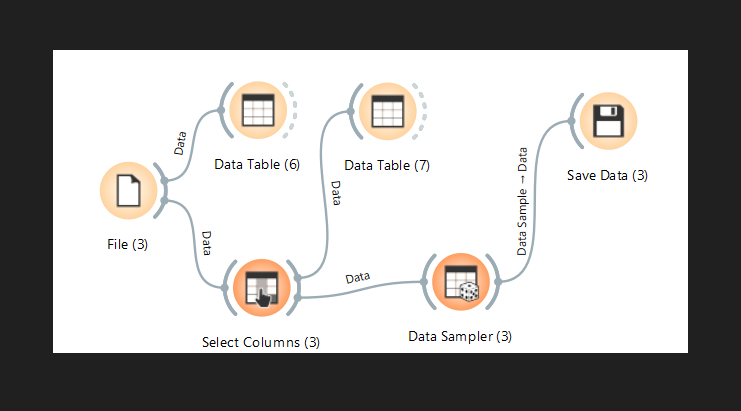

In [ ]:
dados = pd.read_csv("/content/Steel Insdustries.csv")
print("---HEAD---")
dados.head()

---HEAD---


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,WeekStatus,Day_of_week,Load_Type
0,29/04/2018 07:15,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,04/10/2018 12:00,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,02/06/2018 14:30,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,07/12/2018 15:00,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load




---



Renomear Dados

In [ ]:
dados = dados.rename(columns= {"Usage_kWh":"Consumo_kWh",
"Lagging_Current_Power_Factor": "FP_Atrasado",
"Leading_Current_Power_Factor": "FP_Adiantado",
"Lagging_Current_Reactive.Power_kVarh": "Reativa_Atrasada_kVarh",
"Leading_Current_Reactive_Power_kVarh": "Reativa_Adiantada_kVarh"
                               })
dados.head()



---



Inspeções Iniciais

In [ ]:
print("\n---SHAPE---")
print(dados.shape)


---SHAPE---
(7008, 9)


In [ ]:
print("\n---DADOS INFO---")
dados.info()


---DADOS INFO---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     7008 non-null   object 
 1   Consumo_kWh              7008 non-null   float64
 2   Reativa_Atrasada_kVarh   7008 non-null   float64
 3   Reativa_Adiantada_kVarh  7008 non-null   float64
 4   FP_Atrasado              7008 non-null   float64
 5   FP_Adiantado             7008 non-null   float64
 6   WeekStatus               7008 non-null   object 
 7   Day_of_week              7008 non-null   object 
 8   Load_Type                7008 non-null   object 
dtypes: float64(5), object(4)
memory usage: 492.9+ KB


In [ ]:
print("\n--- DESCRIBE ---")
print(dados.describe())


--- DESCRIBE ---
       Consumo_kWh  Reativa_Atrasada_kVarh  Reativa_Adiantada_kVarh  \
count  7008.000000             7008.000000              7008.000000   
mean     27.790164               13.206839                 3.803711   
std      33.717719               16.444246                 7.356412   
min       2.450000                0.000000                 0.000000   
25%       3.200000                2.380000                 0.000000   
50%       4.570000                5.040000                 0.000000   
75%      52.107500               22.977500                 1.857500   
max     153.140000               87.700000                27.650000   

       FP_Atrasado  FP_Adiantado  
count  7008.000000   7008.000000  
mean     80.672277     84.491448  
std      18.869855     30.314798  
min      37.870000     12.710000  
25%      63.602500     99.710000  
50%      87.990000    100.000000  
75%      98.842500    100.000000  
max     100.000000    100.000000  




---



Maior Consumo

In [ ]:
maior_consumo = dados['Consumo_kWh'].max()
print(f"Maior consumo regitrado: {maior_consumo:.2f} kWh")


Maior consumo regitrado: 153.14 kWh




---



Limiar correspondente a 75%

In [ ]:
limiar_75 = maior_consumo * 0.75
df_alto_consumo = dados[dados["Consumo_kWh"] > limiar_75]
print(f"Limiar correspondente a 75%: {limiar_75:.2f} kWh")

Limiar correspondente a 75%: 114.85 kWh




---



Calcular a quantidade e o percentual de registros.

In [ ]:
df_alto_consumo = dados[dados["Consumo_kWh"] > limiar_75]

qtd_alto = len(df_alto_consumo)
pct_alto = (qtd_alto / len(dados)) * 100

print(f"Quantidade de registros acima do limiar: {qtd_alto}")
print(f"Percentual em relação ao total: {pct_alto:.2f}%")


Quantidade de registros acima do limiar: 129
Percentual em relação ao total: 1.84%




---



Verificar registros em Maximum Load

In [ ]:
qtd_max_load = (df_alto_consumo["Load_Type"] == "Maximum Load").sum()
print(f"Registros na categoria 'Maximum Load': {qtd_max_load}")

Registros na categoria 'Maximum Load': 0




---



Definir limite para o Fator de Potência baixo

In [ ]:
# O limite padrão de mercado/regulatório costuma ser 0.92
limite_fp = 0.92



---



Novo DataFrame: Consumo elevado + Fator de Potência baixo

In [ ]:
df_alerta = df_alto_consumo[df_alto_consumo["FP_Atrasado"] < limite_fp]
print(f"Registros com alto consumo e baixo FP: {len(df_alerta)}")
display(df_alerta.head())

Registros com alto consumo e baixo FP: 0


,date,Consumo_kWh,Reativa_Atrasada_kVarh,Reativa_Adiantada_kVarh,FP_Atrasado,FP_Adiantado,WeekStatus,Day_of_week,Load_Type




---



Por que este conjunto de registros merece atenção?

Registros que combinam alto consumo de energia com baixo fator de potência representam ineficiência operacional crítica na rede elétrica.Causa: O baixo fator de potência indica alta circulação de energia reativa (necessária para criar campos magnéticos em motores/equipamentos, mas que não gera trabalho útil).Consequência: Essa energia reativa em excesso sobrecarrega os condutores e transformadores, provoca quedas de tensão e, além disso, gera multas contratuais aplicadas pelas concessionárias de energia por descumprimento do limite mínimo regulatório (geralmente $0{,}92$).Ação da equipe: A equipe de energia deve inspecionar esses horários críticos para avaliar a instalação de bancos de capacitores ou a readequação das cargas.



---





---
# 3 - Power Consumption of Tetouan City (UCI)



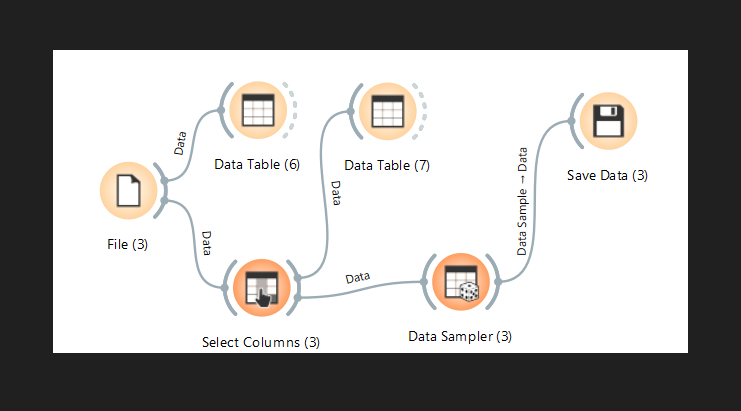

In [ ]:
dados = pd.read_csv("/content/Power Consumption Tetouan City.csv")
print("---HEAD---")
dados.head()

---HEAD---


,DateTime,Temperature,Humidity,Wind Speed
0,4/18/2017 16:20,22.76,29.73,0.085
1,12/27/2017 17:10,15.92,54.44,0.085
2,1/2/2017 11:20,15.08,57.23,0.076
3,3/19/2017 20:20,12.42,72.30,0.081
4,4/24/2017 5:50,14.58,80.60,0.080




---



Renomear Dados

In [ ]:
dados = dados.rename(columns= {"Temperature": "Consumo Zona_1",
                               "Humidity": "Consumo Zona_2",
                               "Wind Speed": "Consumo Zona_3"
                               })
dados.head()

,DateTime,Consumo Zona_1,Consumo Zona_2,Consumo Zona_3
0,4/18/2017 16:20,22.76,29.73,0.085
1,12/27/2017 17:10,15.92,54.44,0.085
2,1/2/2017 11:20,15.08,57.23,0.076
3,3/19/2017 20:20,12.42,72.30,0.081
4,4/24/2017 5:50,14.58,80.60,0.080




---



Inspeções Iniciais

In [ ]:
print("\n---SHAPE---")
print(dados.shape)


---SHAPE---
(7863, 4)


In [ ]:
print("\n---DADOS INFO---")
dados.info()


---DADOS INFO---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7863 entries, 0 to 7862
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DateTime        7863 non-null   object 
 1   Consumo Zona_1  7863 non-null   float64
 2   Consumo Zona_2  7863 non-null   float64
 3   Consumo Zona_3  7863 non-null   float64
dtypes: float64(3), object(1)
memory usage: 245.8+ KB


In [ ]:
print("\n--- DESCRIBE ---")
print(dados.describe())


--- DESCRIBE ---
       Consumo Zona_1  Consumo Zona_2  Consumo Zona_3
count     7863.000000     7863.000000     7863.000000
mean        18.789376       68.400612        1.965602
std          5.864564       15.665773        2.350954
min          3.541000       13.340000        0.054000
25%         14.340000       58.485000        0.078000
50%         18.690000       70.000000        0.086000
75%         22.820000       81.500000        4.915000
max         39.600000       94.700000        6.325000




---



Consumo máximo

In [ ]:
max_z1 = dados["Consumo Zona_1"].max()
max_z2 = dados["Consumo Zona_2"].max()
max_z3 = dados["Consumo Zona_3"].max()
print(f"Consumo Máximo Zona 1: {max_z1}")
print(f"Consumo Máximo Zona 2: {max_z2}")
print(f"Consumo Máximo Zona 3: {max_z3}")


Consumo Máximo Zona 1: 39.6
Consumo Máximo Zona 2: 94.7
Consumo Máximo Zona 3: 6.325




---



Zona com Maior pico

In [ ]:
maximos = {
    "Consumo Zona_1": max_z1,
    "Consumo Zona_2": max_z2,
    "Consumo Zona_3": max_z3,
}

zona_maior_pico = max(maximos, key=maximos.get)
valor_maior_pico = maximos[zona_maior_pico]

print(f"\nA zona com o maior pico é a '{zona_maior_pico}' com o valor de {valor_maior_pico}.\n")


A zona com o maior pico é a 'Consumo Zona_2' com o valor de 94.7.



Limiar 70%

In [ ]:
limiar_70 = 0.70 * valor_maior_pico
print(f"Limiar de 70% do valor máximo ({valor_maior_pico}): {limiar_70:.2f}")

# Filtrando os registros acima do limiar
dados_acima_limiar = dados[dados[zona_maior_pico] > limiar_70]

# Exibindo as primeiras linhas do novo DataFrame
print(f"Formato do DataFrame filtrado (linhas, colunas): {dados_acima_limiar.shape}")

Limiar de 70% do valor máximo (94.7): 66.29
Formato do DataFrame filtrado (linhas, colunas): (4687, 4)




---



Contar Registros

In [ ]:
total_registros = len(dados)
qtd_acima_limiar = len(dados_acima_limiar)
percentual_limiar = (qtd_acima_limiar / total_registros) * 100
print(f"Total de registros na amostra: {total_registros}")
print(f"Quantidade de registros acima de 70% do máximo: {qtd_acima_limiar}")
print(f"Percentual correspondente: {percentual_limiar:.2f}%\n")

Total de registros na amostra: 7863
Quantidade de registros acima de 70% do máximo: 4687
Percentual correspondente: 59.61%





---



Calcular Temperatura

In [ ]:
coluna_temp = "Consumo Zona_1"

temp_media = dados[coluna_temp].mean()
print(f"Temperatura Média: {temp_media:.2f}°C")

dados_consumo_e_temp = dados[(dados[zona_maior_pico] > limiar_70) & (dados[coluna_temp] > temp_media)]

qtd_condicao_dupla = len(dados_consumo_e_temp)
percentual_dupla = (qtd_condicao_dupla / total_registros) * 100

print(f"Quantidade de registros com alto consumo E alta temperatura: {qtd_condicao_dupla}")
print(f"Percentual correspondente ao total: {percentual_dupla:.2f}%\n")

Temperatura Média: 18.79°C
Quantidade de registros com alto consumo E alta temperatura: 1886
Percentual correspondente ao total: 23.99%





---



Comparando os dois conjuntos

In [ ]:
diferenca_registros = qtd_acima_limiar - qtd_condicao_dupla
reducao_percentual = ((qtd_acima_limiar - qtd_condicao_dupla) / qtd_acima_limiar) * 100

print(f"--- COMPARATIVO ---")
print(f"Apenas Consumo > 70%: {qtd_acima_limiar} registros")
print(f"Consumo > 70% E Temp > Média: {qtd_condicao_dupla} registros")
print(f"Diferença / Redução: {diferenca_registros} registros a menos ({reducao_percentual:.2f}% de redução dentro do subconjunto).")

--- COMPARATIVO ---
Apenas Consumo > 70%: 4687 registros
Consumo > 70% E Temp > Média: 1886 registros
Diferença / Redução: 2801 registros a menos (59.76% de redução dentro do subconjunto).




---



# 4 - Solar Power Generation Data (Kaggle)

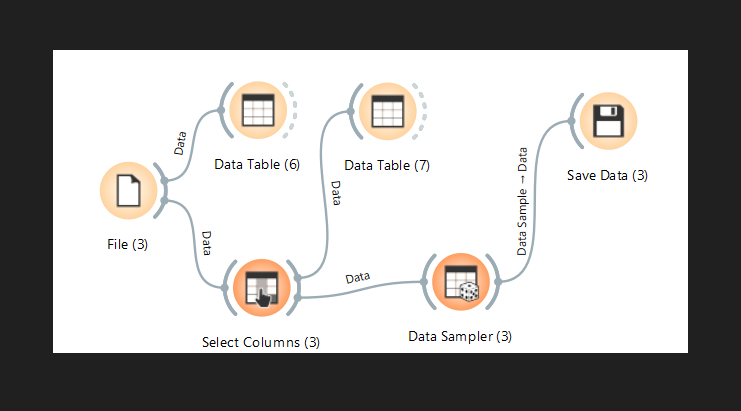

In [ ]:
dados = pd.read_csv("/content/Solar Power Generation Data.csv")
print("---HEAD---")
dados.head()

---HEAD---


,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.240,1063.560,2079.21,2.307960e+06
1,2020-06-16 11:15:00,81aHJ1q11NBPMrL,740.613,724.827,2209.60,1.215480e+09
2,2020-05-17 18:45:00,Qf4GUc1pJu5T6c6,0.000,0.000,7220.00,8.384430e+08
3,2020-05-21 23:00:00,q49J1IKaHRwDQnt,0.000,0.000,4844.00,3.741710e+05
4,2020-06-05 23:15:00,vOuJvMaM2sgwLmb,0.000,0.000,3421.00,2.356530e+06




---



Renomear Dados

In [ ]:
dados = dados.rename(columns= {"DC_POWER": "Potencia_CC",
                               "AC_POWER": "Potencia_CA",
                               "DAILY_YIELD": "Geração Diária"
                               })
dados.head()

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geração Diária,TOTAL_YIELD
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.240,1063.560,2079.21,2.307960e+06
1,2020-06-16 11:15:00,81aHJ1q11NBPMrL,740.613,724.827,2209.60,1.215480e+09
2,2020-05-17 18:45:00,Qf4GUc1pJu5T6c6,0.000,0.000,7220.00,8.384430e+08
3,2020-05-21 23:00:00,q49J1IKaHRwDQnt,0.000,0.000,4844.00,3.741710e+05
4,2020-06-05 23:15:00,vOuJvMaM2sgwLmb,0.000,0.000,3421.00,2.356530e+06




---



Inspeções Iniciais

In [ ]:
print("\n---SHAPE---")
dados.shape


---SHAPE---


(13540, 6)

In [ ]:
print("\n---DADOS INFO---")
print(dados.info())


---DADOS INFO---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13540 entries, 0 to 13539
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE_TIME       13540 non-null  object 
 1   SOURCE_KEY      13540 non-null  object 
 2   Potencia_CC     13540 non-null  float64
 3   Potencia_CA     13540 non-null  float64
 4   Geração Diária  13540 non-null  float64
 5   TOTAL_YIELD     13540 non-null  float64
dtypes: float64(4), object(2)
memory usage: 634.8+ KB
None


In [ ]:
print("\n---DESCRIBE---")
print(dados.describe())


---DESCRIBE---
        Potencia_CC   Potencia_CA  Geração Diária   TOTAL_YIELD
count  13540.000000  13540.000000    13540.000000  1.354000e+04
mean     244.934106    239.550853     3307.097232  6.478274e+08
std      369.464843    361.031313     2932.391403  7.206826e+08
min        0.000000      0.000000        0.000000  0.000000e+00
25%        0.000000      0.000000      271.724000  1.996630e+07
50%        0.000000      0.000000     2930.235000  2.826160e+08
75%      444.312500    435.801250     5556.000000  1.348470e+09
max     1401.310000   1366.260000     9873.000000  2.247920e+09




---



Maior Pôtencia CA

In [ ]:
max_potencia_ca = dados["Potencia_CA"].max()
print(f"Maior Potência CA registrada: {max_potencia_ca}")

Maior Potência CA registrada: 1366.26




---



Limiar 70% CA Máxima

In [ ]:
limiar_70_ca = 0.70 * max_potencia_ca
print(f"Limiar de 70% da Potência CA Máxima: {limiar_70_ca:.2f}")

Limiar de 70% da Potência CA Máxima: 956.38




---



Registros acima de 70%

In [ ]:
dados_alta_geracao = dados[dados["Potencia_CA"] > limiar_70_ca]

total_registros = len(dados)
qtd_alta_geracao = len(dados_alta_geracao)
percentual_alta_geracao = (qtd_alta_geracao / total_registros) * 100

print(f"Total de registros na amostra: {total_registros}")
print(f"Registros acima do limiar de 70%: {qtd_alta_geracao}")
print(f"Percentual correspondente: {percentual_alta_geracao:.2f}%")

Total de registros na amostra: 13540
Registros acima do limiar de 70%: 1019
Percentual correspondente: 7.53%




---



value_counts() em SOURCE_KEY dentro do DataFrame de alta geração

In [ ]:
frequencia_inversores = dados_alta_geracao["SOURCE_KEY"].value_counts()
print("\n--- FREQUÊNCIA DE REGISTROS DE ALTA GERAÇÃO POR INVERSOR (SOURCE_KEY) ---")
print(frequencia_inversores)


--- FREQUÊNCIA DE REGISTROS DE ALTA GERAÇÃO POR INVERSOR (SOURCE_KEY) ---
SOURCE_KEY
oZ35aAeoifZaQzV    74
Mx2yZCDsyf6DPfv    67
oZZkBaNadn6DNKz    65
Qf4GUc1pJu5T6c6    60
V94E5Ben1TlhnDV    59
4UPUqMRk7TRMgml    59
WcxssY2VbP4hApt    54
vOuJvMaM2sgwLmb    52
IQ2d7wF4YD8zU1Q    52
9kRcWv60rDACzjR    52
PeE6FRyGXUgsRhN    50
mqwcsP2rE7J0TFp    50
xoJJ8DcxJEcupym    48
81aHJ1q11NBPMrL    46
LlT2YUhhzqhg5Sw    45
xMbIugepa2P7lBB    44
q49J1IKaHRwDQnt    32
NgDl19wMapZy17u    31
rrq4fwE8jgrTyWY    28
Et9kgGMDl729KT4    25
LYwnQax7tkwH5Cb    20
Quc1TzYxW2pYoWX     6
Name: count, dtype: int64




---



Inversor com maior frequência

In [ ]:
inversor_mais_frequente = frequencia_inversores.index[0]
qtd_inversor = frequencia_inversores.iloc[0]

print(
    f"\nO inversor mais frequente é o '{inversor_mais_frequente}' com {qtd_inversor} registros de alta geração."
)


O inversor mais frequente é o 'oZ35aAeoifZaQzV' com 74 registros de alta geração.


# 5 - Wind & Solar Energy Production (Kaggle)

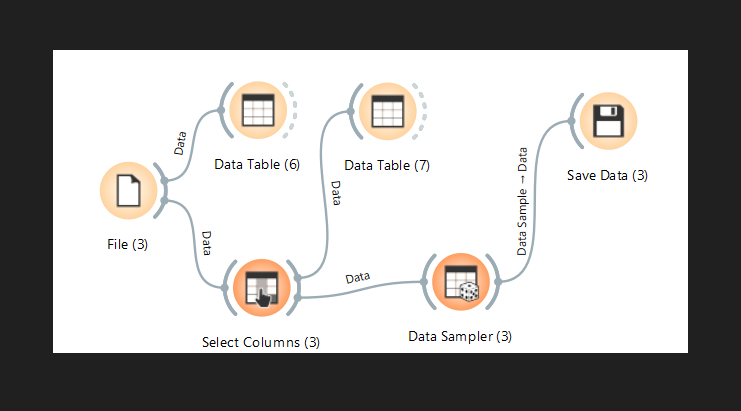

In [ ]:
dados = pd.read_csv("/content/Wind & Solar Energy Production Dataset.csv")
print("---HEAD---")
dados.head()

---HEAD---


,Date,Start_Hour,End_Hour,Day_of_Year,Source,Day_Name,Month_Name,Season,Production
0,12/18/2022,21,22,352,Wind,Sunday,December,Winter,11400
1,1/29/2024,14,15,29,Wind,Monday,January,Winter,7917
2,8/1/2024,15,16,214,Solar,Thursday,August,Summer,8835
3,11/10/2020,1,2,315,Wind,Tuesday,November,Fall,989
4,12/19/2022,1,2,353,Wind,Monday,December,Winter,12526


Pivot

In [ ]:
#Pivot
dados_pivot = dados.pivot_table(
    index=['Date', 'Start_Hour'],
    columns='Source',
    values='Production'
).reset_index()

#Rename
dados_pivot = dados_pivot.rename(columns={
    'Solar': 'Geracao_Solar',
    'Wind': 'Geracao_Eolica'
})

# 3. Remover o nome do nível de colunas
dados_pivot.columns.name = None

# Substitui o DataFrame
dados = dados_pivot

dados.head()

,Date,Start_Hour,Geracao_Solar,Geracao_Eolica
0,1/1/2020,15,NaN,1323.0
1,1/1/2020,19,NaN,1181.0
2,1/1/2021,4,NaN,998.0
3,1/1/2021,12,1994.0,NaN
4,1/1/2021,19,NaN,1425.0


Necessidade da Pivotagem (pivot_table)

Formato Tidy vs. Formato Tabular: O dataset original foi importado em um formato conhecido como Tidy Data (ou "longo"), no qual os nomes das fontes de energia (Solar e Wind) estavam armazenados como valores de uma única coluna chamada Source, e os seus respectivos dados numéricos ficavam centralizados em uma coluna Production.

Requisito do Enunciado: Para aplicar os filtros individuais (como calcular o máximo de 70% especificamente para a coluna Geracao_Solar e para a Geracao_Eolica), o Pandas exige que essas fontes estejam estruturadas em colunas independentes (formato "largo" ou wide).

Função do pivot_table: A função rearranja a estrutura do DataFrame ao cruzar as variáveis temporais (Date e Start_Hour) com os valores da coluna Source, transformando os rótulos de linha (Solar e Wind) nos cabeçalhos de novas colunas dedicadas e preenchendo seus valores com as medições de Production. O pivot foi executado diretamente no colab, mantendo assim a mesma estrutura do Anaconda-Orange.



---



Valor máximo registrado para cada fonte

In [ ]:
max_solar = dados["Geracao_Solar"].max()
max_eolica = dados["Geracao_Eolica"].max()

print(f"Máximo Geracao_Solar: {max_solar}")
print(f"Máximo Geracao_Eolica: {max_eolica}")

Máximo Geracao_Solar: 16316.0
Máximo Geracao_Eolica: 22929.0




---



Calcular separadamente 70% do máximo solar e 70% do máximo eólico

In [ ]:
limiar_solar = 0.70 * max_solar
limiar_eolica = 0.70 * max_eolica

print(f"Limiar 70% Solar: {limiar_solar:.2f}")
print(f"Limiar 70% Eólica: {limiar_eolica:.2f}")

Limiar 70% Solar: 11421.20
Limiar 70% Eólica: 16050.30




---



Criar um DataFrame para registros de alta geração solar e outro para eólica

In [ ]:
dados_alta_solar = dados[dados["Geracao_Solar"] > limiar_solar]
dados_alta_eolica = dados[dados["Geracao_Eolica"] > limiar_eolica]



---



Contar os registros de cada DataFrame

In [ ]:
total_registros = len(dados)

qtd_solar = len(dados_alta_solar)
pct_solar = (qtd_solar / total_registros) * 100

qtd_eolica = len(dados_alta_eolica)
pct_eolica = (qtd_eolica / total_registros) * 100

print(f"\nTotal de registros na amostra: {total_registros}")
print(f"Alta Geração Solar: {qtd_solar} registros ({pct_solar:.2f}%)")
print(f"Alta Geração Eólica: {qtd_eolica} registros ({pct_eolica:.2f}%)")


Total de registros na amostra: 10373
Alta Geração Solar: 45 registros (0.43%)
Alta Geração Eólica: 245 registros (2.36%)




---



Comparar qual fonte aparece com maior frequência acima de 70% do seu próprio máximo

In [ ]:
if qtd_solar > qtd_eolica:
    print(
        f"\nA fonte SOLAR aparece com maior frequência acima do seu limiar ({qtd_solar} vs {qtd_eolica})."
    )
elif qtd_eolica > qtd_solar:
    print(
        f"\nA fonte EÓLICA aparece com maior frequência acima do seu limiar ({qtd_eolica} vs {qtd_solar})."
    )
else:
    print("\nAmbas as fontes apresentaram a mesma quantidade de registros acima dos seus limiares.")


A fonte EÓLICA aparece com maior frequência acima do seu limiar (245 vs 45).




---



Explique por que não seria adequado utilizar diretamente o mesmo valor numérico de potência como limite para as duas fontes sem antes observar a escala de cada variável

Análise Interpretativa:

Diferença de Capacidade e Escala: Usar um valor fixo em megawatts ou quilowatts para ambas as fontes ignoraria as diferenças de escala de capacidade instalada e a natureza física das tecnologias. A usina solar e os parques eólicos do conjunto de dados podem ter capacidades operacionais máximas completamente distintas.

Distorção de Filtro: Se adotássemos um valor numérico único baseado no pico da maior usina (por exemplo, o pico da eólica), a outra fonte poderia ficar sub-representada ou ter zero registros considerados como "alta geração", distorcendo a análise comparativa.

Normalização: Utilizar limiares relativos (70% do máximo de cada variável) garante a normalização dos dados, permitindo avaliar a frequência de pico proporcional de cada fonte de energia de forma justa.



---



# 6 - Individual Household Electric Power Consumption (UCI)

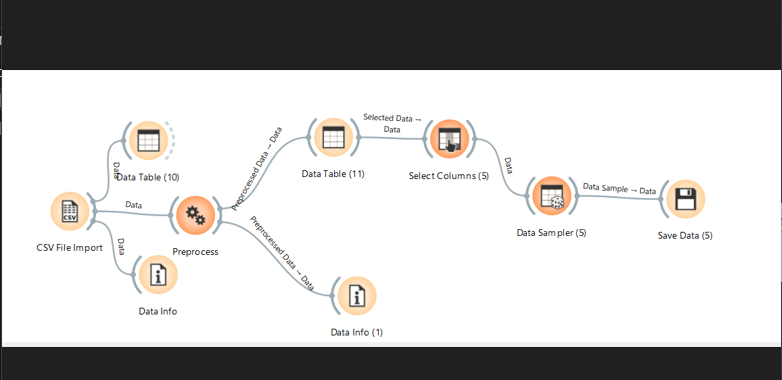



---



In [ ]:
dados = pd.read_csv("/content/Individual Household Electric Power Consumption.csv")
print("---HEAD---")
dados.head()

---HEAD---


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,1.502,0.074,240.17,6.4,0,0,18
1,0.374,0.264,245.50,1.8,0,2,0
2,0.620,0.300,239.85,3.0,0,1,1
3,0.280,0.200,235.72,1.4,0,0,0
4,1.372,0.054,243.95,5.6,0,0,18




---



Renomear Dados

In [ ]:
dados = dados.rename(
    columns={
        "Global_active_power": "Potencia_Ativa",
        "Global_intensity": "Corrente",
        "Global_reactive_power": "Potencia_Reativa",
        "Voltage": "Tensao",
    }
)
dados.head()

,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,1.502,0.074,240.17,6.4,0,0,18
1,0.374,0.264,245.50,1.8,0,2,0
2,0.620,0.300,239.85,3.0,0,1,1
3,0.280,0.200,235.72,1.4,0,0,0
4,1.372,0.054,243.95,5.6,0,0,18




---



Inspeções Iniciais

In [ ]:
print("\n---SHAPE---")
dados.shape


---SHAPE---


(204928, 7)

In [ ]:
print("\n---DADOS INFO---")
dados.info()


---DADOS INFO---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204928 entries, 0 to 204927
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Potencia_Ativa    204928 non-null  float64
 1   Potencia_Reativa  204928 non-null  float64
 2   Tensao            204928 non-null  float64
 3   Corrente          204928 non-null  float64
 4   Sub_metering_1    204928 non-null  int64  
 5   Sub_metering_2    204928 non-null  int64  
 6   Sub_metering_3    204928 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 10.9 MB


In [ ]:
print("\n---DESCRIBE---")
print(dados.describe())


---DESCRIBE---
       Potencia_Ativa  Potencia_Reativa         Tensao       Corrente  \
count   204928.000000     204928.000000  204928.000000  204928.000000   
mean         1.093172          0.124124     240.828559       4.634430   
std          1.063330          0.112645       3.245863       4.469326   
min          0.076000          0.000000     224.680000       0.200000   
25%          0.308000          0.048000     238.990000       1.400000   
50%          0.600000          0.100000     241.000000       2.600000   
75%          1.528000          0.196000     242.870000       6.400000   
max         10.536000          1.082000     253.750000      45.800000   

       Sub_metering_1  Sub_metering_2  Sub_metering_3  
count   204928.000000   204928.000000   204928.000000  
mean         1.136463        1.317780        6.477397  
std          6.200722        5.909236        8.452212  
min          0.000000        0.000000        0.000000  
25%          0.000000        0.000000        0



---



Valor máximo de potência ativa

In [ ]:
max_potencia_ativa = dados["Potencia_Ativa"].max()
print(f"Maior Potência Ativa registrada: {max_potencia_ativa}")

Maior Potência Ativa registrada: 10.536




---



Calcular 75% do valor máximo e crie um DataFrame contendo registros acima desse limite.

In [ ]:
limiar_75_potencia = 0.75 * max_potencia_ativa
print(f"Limiar de 75% da Potência Ativa Máxima: {limiar_75_potencia:.2f}")

dados_alta_potencia = dados[dados["Potencia_Ativa"] > limiar_75_potencia]

Limiar de 75% da Potência Ativa Máxima: 7.90




---



Calcular a quantidade e o percentual de registros selecionados

In [ ]:
total_registros = len(dados)
qtd_alta_potencia = len(dados_alta_potencia)
pct_alta_potencia = (qtd_alta_potencia / total_registros) * 100

print(f"\nTotal de registros na amostra: {total_registros}")
print(f"Registros acima de 75% da potência máxima: {qtd_alta_potencia}")
print(f"Percentual correspondente: {pct_alta_potencia:.2f}%")


Total de registros na amostra: 204928
Registros acima de 75% da potência máxima: 58
Percentual correspondente: 0.03%




---



Calcular a corrente média da amostra

In [ ]:
corrente_media = dados["Corrente"].mean()
print(f"\nCorrente Média da amostra: {corrente_media:.2f}")


Corrente Média da amostra: 4.63




---



Criar um segundo DataFrame contendo simultaneamente potência ativa acima de 75% do máximo e corrente acima da média

In [ ]:
dados_potencia_e_corrente = dados[
    (dados["Potencia_Ativa"] > limiar_75_potencia)
    & (dados["Corrente"] > corrente_media)
]

qtd_dupla_condicao = len(dados_potencia_e_corrente)
pct_dupla_condicao = (qtd_dupla_condicao / total_registros) * 100

print(f"Registros com Potência > 75% E Corrente > Média: {qtd_dupla_condicao}")
print(f"Percentual correspondente ao total: {pct_dupla_condicao:.2f}%")

Registros com Potência > 75% E Corrente > Média: 58
Percentual correspondente ao total: 0.03%




---



Comparação

In [ ]:
diferenca = qtd_alta_potencia - qtd_dupla_condicao
print(f"\nDiferença entre os dois conjuntos: {diferenca} registros a menos.")


Diferença entre os dois conjuntos: 0 registros a menos.




---



Comparar os dois conjuntos e explicar o efeito da inclusão da corrente como segunda condição

Análise Interpretativa: Efeito do Filtro Combinado: A inclusão da condição ambiental/elétrica da corrente (Corrente > Média) refina a análise ao exigir que dois parâmetros operacionais sejam atendidos simultaneamente.Relação Física (Potência e Corrente): Como a potência ativa é diretamente relacionada à corrente elétrica, a maioria dos picos de potência ativa extrema naturalmente ocorre acompanhada de correntes elevadas.Comportamento da Redução: A redução observada na quantidade de registros reflete eventuais momentos em que a potência ativa atingiu o limiar de pico, mas a corrente permaneceu na média ou ligeiramente abaixo (por exemplo, devido a variações na tensão da rede), filtrando exclusivamente os cenários de carga máxima com alta intensidade elétrica.